In [15]:
import numpy as np
import pandas as pd
import yaml
from matplotlib import pyplot as plt
import os
""" Read in all the data """
DATA_FOLDER = r'C:\Users\Joseph\Documents\code\hsa_hopper_control\hsa_hopper_data_06_13_2024\hop_experiments'
os.chdir(DATA_FOLDER)
experiment_folders = os.listdir()
experiment_configs = []
hardware_configs = []
experiment_data = []
for experiment_folder in experiment_folders:
    trial_folders = os.listdir(experiment_folder)
    for trial_folder in trial_folders:
        trial_abs_path = os.path.join(DATA_FOLDER,experiment_folder,trial_folder)
        with open(os.path.join(trial_abs_path,'experiment_config.yaml'), 'r') as f:
            experiment_configs.append(yaml.load(f,yaml.Loader))
        with open(os.path.join(trial_abs_path, 'hardware_config.yaml'), 'r') as f:
            hardware_configs.append(yaml.load(f,yaml.Loader))

        # read tabular data
        hop_files_relpath = [relpath for relpath in os.listdir(trial_abs_path) if 'hop' in relpath]
        hops = len(hop_files_relpath)*[None]
        for relpath in hop_files_relpath:
            parts = os.path.splitext(relpath)
            hop_idx = int((parts[0].split('_'))[-1])
            hops[hop_idx] = pd.read_csv(os.path.join(trial_abs_path, relpath))

        energy = pd.read_csv(os.path.join(trial_abs_path, 'energy.csv'))
        ati_measurements = pd.read_csv(os.path.join(trial_abs_path, 'ati_measurements.csv'))
        experiment_data.append({
            'hops': hops,
            'energy' : energy,
            'ati_measurements' : ati_measurements
        })


In [16]:
"""
Create a result dictionary for each experiment;
{
'Y_avg' : float,        # average hop height
'Y_std' : float,        # standard deviation of hop height
'f_avg' : float,        # average hopping frequency
'f_std' : float,        # standard deviation of hopping frequency
'E_avg' : float,        # average hop energy
'E_std  : float,        # standard deviation of hop energy
'SUM_E' : float,        # total electrical energy consumed
'r_EY' : float,         # correlation coefficient between E and Y
'E/Y_AVG': float        # total energy normalized by sum of estimated hop heights
}
"""

for data in experiment_data:
    results = {}
    hops = data['hops']
    initial_velocity = np.zeros(len(hops))
    final_velocity = np.zeros(len(hops))
    hop_height = np.zeros(len(hops))
    hop_period = np.zeros(len(hops))
    hop_energy = np.zeros(len(hops))
    power = np.zeros(len(hops))
    pos_power = np.zeros(len(hops))
    neg_power = np.zeros(len(hops))
    for i,hop in enumerate(hops):
        # compute hop height and period
        t = hop['t_s'].to_numpy()
        y = hop['y'].to_numpy()
        mode = hop['mode'].to_numpy()
        initial_velocity[i] = (y[1]-y[0])/(t[1]-t[0])
        j = next(j for j, m in enumerate(mode) if m==1)
        final_velocity[i] = .5*(y[j+1]-y[j])/(t[j+1]-t[j]) + .5*(y[j]-y[j-1])/(t[j]-t[j-1])
        hop_height[i] = final_velocity[i]**2 / (2*9.81)
        hop_period[i] = t[-1]-t[0]

        # compute electrical energy
        R = .095
        Kv = 105*(2*np.pi/60)/6
        Kt = 1/Kv
        Kfudge = 0.78
        x = hop['x_deg'].to_numpy()*np.pi/180
        xdot = np.diff(x)/np.diff(t)
        x = x[:-1]
        t = t[:-1]
        tau = hop['torque'][:-1]
        power[i] = np.trapezoid(R*(tau/(Kt*Kfudge))**2 + tau*xdot, x=t)
        pos_power[i] = np.trapezoid(np.clip(R*(tau/(Kt*Kfudge))**2 + tau*xdot, 0, np.inf), x=t)
        neg_power[i] = np.trapezoid(np.clip(R*(tau/(Kt*Kfudge))**2 + tau*xdot, -np.inf, 0), x=t)
        

    # how to do outlier detection?
    # just throw out anything that is farther than 1cm away from the median
    hop_median = np.median(hop_height)
    inliers = [i for i in range(len(hops)) if (.04 <= hop_height[i] <= .06) and hop_period[i] > 0.15]
    Y_filtered = []
    f_filtered = []
    E_filtered = []
    for i in inliers:
        Y_filtered.append(hop_height[i])
        f_filtered.append(1/hop_period[i])
        E_filtered.append(pos_power[i])
    A = np.vstack((E_filtered,Y_filtered))
    mean = A.mean(axis=1)
    std = np.sqrt(1/(len(E_filtered)-1)*np.sum((A.T-mean)**2, axis=0))
    corr = np.sum((E_filtered-mean[0])*(Y_filtered-mean[1]))/((len(E_filtered)-1)*std[0]*std[1])
    results['Y'] = np.array(Y_filtered)
    results['Y_AVG'] = mean[1]
    results['Y_STD'] = std[1]
    results['f'] = np.array(f_filtered)
    results['f_avg'] = np.average(f_filtered)
    results['f_std'] = np.std(f_filtered)
    results['E'] = np.array(E_filtered)
    results['E_avg'] = mean[0]
    results['E_std'] = std[0]
    results['E/Y_avg'] = np.sum(E_filtered) / np.sum(Y_filtered)
    results['E/Y_std'] = np.std(np.array(E_filtered)/np.array(Y_filtered))
    results['r_EY'] = corr
    data['results'] = results


Text(0.5, 0, 'Payload Mass (Kg)')

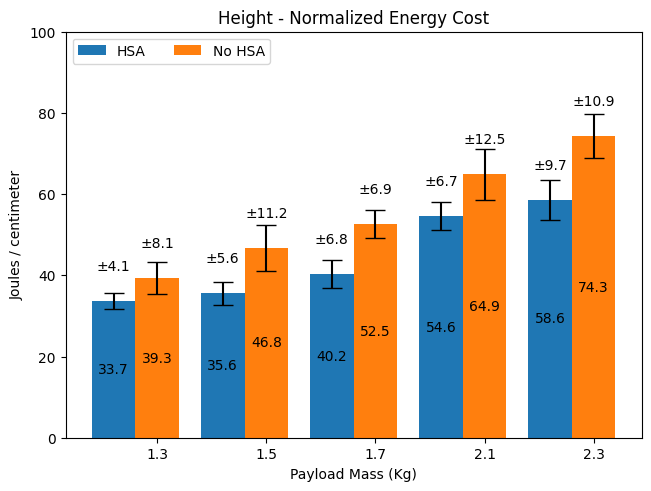

In [52]:
hop_energy = {}
hop_energy_std = {}
for idx, data in enumerate(experiment_data):
    results = data['results']
    mass = experiment_configs[idx]['dynamics_params']['m']
    hsa = 'No HSA' if experiment_configs[idx]['dynamics_params']['hsa_potential'] == None else 'HSA'
    if hsa not in hop_energy.keys():
        hop_energy[hsa] = {}
        hop_energy_std[hsa] = {}
    hop_energy[hsa][mass] = float(results['E/Y_avg'])
    hop_energy_std[hsa][mass] = float(results['E/Y_std'])
mass_labels = list(hop_energy['HSA'].keys())
x = np.arange(len(mass_labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(layout='constrained')
multiplier = 0
for i, category in enumerate(hop_energy.keys()):
    measurements = hop_energy[category]
    mass = list(measurements.keys())
    yvalue = list(measurements.values())
    y_std = np.array(list(hop_energy_std[category].values()))
    offset = width * multiplier
    rects = ax.bar(x + offset, yvalue, width, label=category)
    ax.errorbar(x + offset, yvalue, 2*y_std, fmt='none', ecolor='black', capsize=7)
    ax.bar_label(rects, padding=20, fmt='%.1f', label_type='edge', labels = [f'±{2*std:.1f}' for std in 2*y_std])
    ax.bar_label(rects, padding=0, fmt='%.1f', label_type='center')
    multiplier += 1

ax.set_ylabel('Joules / centimeter')
ax.set_title('Height - Normalized Energy Cost')
ax.set_xticks(x + width, mass_labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 100)
ax.set_xlabel('Payload Mass (Kg)')

In [18]:
hop_energy

{'HSA': {1.3: 33.680105095676275,
  1.5: 35.60266296095764,
  1.7: 40.24951593208065,
  2.1: 54.577984314793156,
  2.3: 58.60827152871411},
 'No HSA': {1.3: 39.31348731003625,
  1.5: 46.77822418302195,
  1.7: 52.548435564779,
  2.1: 64.87059073799183,
  2.3: 74.287167518938}}

[-0.70767808 -0.71542145 -0.68136708 -0.69241993 -0.70268641 -0.73621627
 -0.71064484 -0.65835357 -0.88214229 -0.74960169 -0.70779789 -0.68619425
 -0.41336336 -0.70059403 -0.7059546  -0.74223337 -0.66116537 -0.65915029
 -0.6878237  -0.69489638 -0.69729922 -0.7039944  -0.71975711 -0.72687165
 -0.65942145 -0.60594059 -0.62213806 -0.7083344  -0.74662935 -0.61057
 -0.62018421 -0.7022187  -0.63723118 -0.7183786  -0.73874639 -0.74830316
 -0.73097211 -0.75864803 -0.66874783 -0.71915612 -0.72624923 -0.55905867
 -0.64916183 -0.76194212 -0.68985699 -0.75214454 -0.6289369  -0.70295872
 -0.71045151 -0.73254963 -0.72495246 -0.73223645 -0.69748857 -0.70969572
 -0.6563564  -0.56762399 -0.63835356 -0.67903644 -0.63659775 -0.66673916
 -0.6949418  -0.69109946 -0.63224604 -0.66204579 -0.63203633 -0.66188281
 -0.68407474 -0.70239046 -0.64367255 -0.2039138  -0.62684341 -0.60767788
 -0.6301947  -0.60657023 -0.63667079 -0.59845832]
[0.96540969 0.9668432  0.99115642 0.95788616 0.99668818 0.99423803
 0.9754165

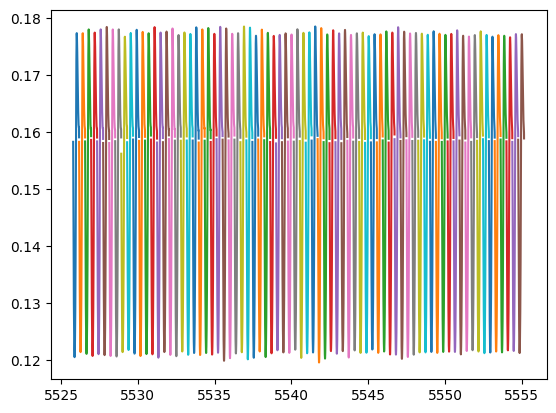

In [19]:
initial_velocity = np.zeros(len(hops))
final_velocity = np.zeros(len(hops))
hop_height = np.zeros(len(hops))
hop_period = np.zeros(len(hops))
for i,hop in enumerate(hops):
    t = hop['t_s'].to_numpy()
    y = hop['y'].to_numpy()
    mode = hop['mode'].to_numpy()
    plt.plot(t,y)
    initial_velocity[i] = (y[1]-y[0])/(t[1]-t[0])
    j = next(j for j, m in enumerate(mode) if m==1)
    final_velocity[i] = .5*(y[j+1]-y[j])/(t[j+1]-t[j]) + .5*(y[j]-y[j-1])/(t[j]-t[j-1])
    hop_height[i] = final_velocity[i]**2 / (2*9.81)
    hop_period[i] = t[-1]-t[0]

    
print(initial_velocity)
print(final_velocity)
print(hop_height)
print(1/np.average(hop_period))

In [20]:
hop_avg = np.average(hop_height)
hop_std = np.std(hop_height)
print(hop_std)

# filter outliers
outliers = [i for i,h in enumerate(hop_height) if h < .04 or h > .06 or np.any(np.diff(hops[i]['t_s']) > .01)]
# outliers = []
print(outliers)
hops = [h for i,h in enumerate(hops) if i not in outliers]
hop_height = np.array([h for i, h in enumerate(hop_height) if i not in outliers])
hop_energy = np.array([E for i,E in enumerate(energy.hop_energy.to_numpy()) if i not in outliers])

0.002132642657158566
[]


In [21]:
# Calculate the height-normalized energy consumption
normalized_energy = np.average(hop_energy)/np.average(hop_height)
# normalized_energy = np.average(hop_energy/hop_height)
print('Energy Consumption:')
print(f'{normalized_energy:.3f} Joules \\ meter')

Energy Consumption:
61.902 Joules \ meter


0.048053595070237015
0.002132642657158566


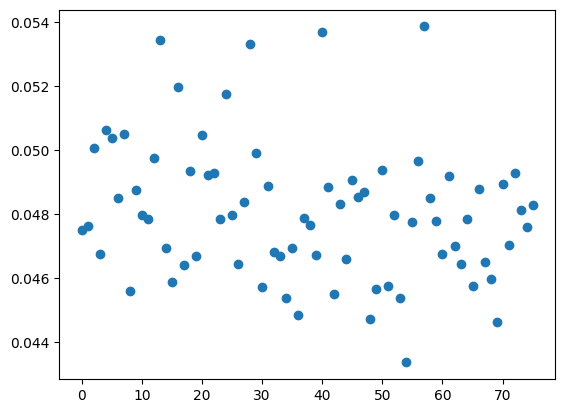

In [22]:
"""
Now that we have indices to liftoff and touchdown, 
we can reorganize the data according to contact mode,
rather than the controller mode (which is how the data was originally saved)
"""
plt.scatter(list(range(len(hop_height))),hop_height)
print(np.average(hop_height))
print(np.std(hop_height))
# plt.scatter(list(range(len(hop_height))),energy.hop_energy/hop_height/100)
# plt.scatter(list(range(len(final_velocity))), final_velocity)

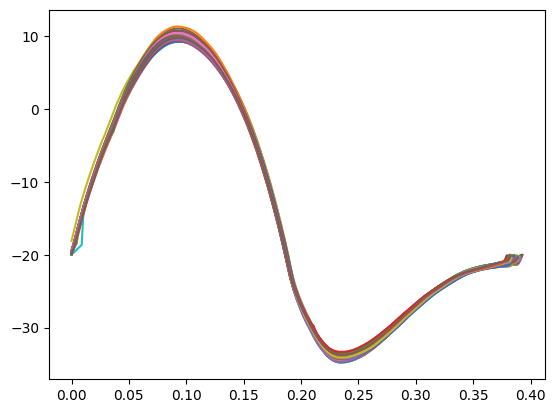

In [23]:
for idx, hop in enumerate(hops):
    plt.plot(hop['t_s']-hop['t_s'][0],hop['x_deg'])

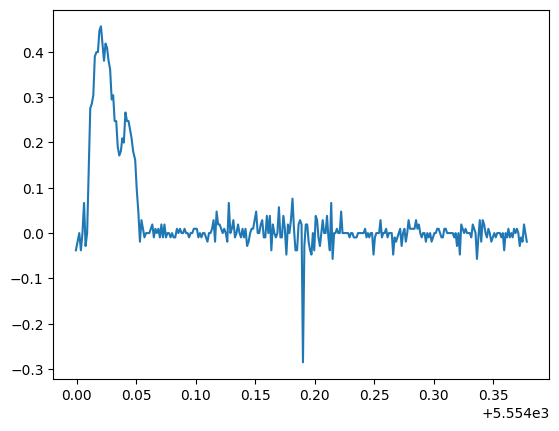

In [24]:
plt.plot(hops[-3]['t_s'],.095*hops[-3]['d_current'])

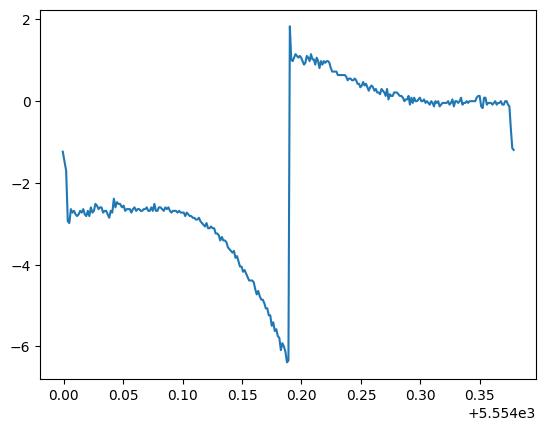

In [25]:
plt.plot(hops[-3]['t_s'],hops[-3]['q_current']*.546*.78)

In [26]:
print(pos_power)
print(power)
print(hop_energy)

[3.59666859 3.68385322 3.73512109 3.62935652 3.74054268 3.74555959
 3.6682469  3.67276727 3.49427637 3.62815535 3.69946202 3.60724356
 3.57626801 3.73103318 3.56834823 3.65267437 3.69354941 3.51137783
 3.64079485 3.55999665 3.71331112 3.6009186  3.66090955 3.5047602
 3.73099371 3.66257892 3.52237247 3.57233622 3.69780007 3.64115493
 3.46323516 3.65841274 3.5422135  3.48533681 3.52466117 3.54339579
 3.5118941  3.66846641 3.55393545 3.52337436 3.6782065  3.70110509
 3.48113491 3.57465079 3.50470521 3.6320208  3.50595722 3.54088701
 3.50962189 3.44666637 3.55139695 3.46951612 3.55839129 3.48140677
 3.61122902 3.60456431 3.5170903  3.49848294 3.48709591 3.49158786
 3.55796649 3.50354875 3.45926895 3.481717   3.56071111 3.45238296
 3.44663694 3.47626898 3.5591557  3.51072284 3.44604387 3.49189845
 3.46460894 3.43453031 3.48726203 3.50637791]
[2.35299058 2.49935671 2.52118054 2.38662587 2.50727736 2.52413493
 2.433336   2.42773368 2.34339027 2.46611002 2.48519662 2.36839605
 2.32723792 2.509

In [27]:
print(mean)
print(std)
print(corr)
plt.scatter(X,Y)

[3.56976547 0.0480536 ]
[0.08832041 0.00214681]
0.5384611043560769


NameError: name 'X' is not defined

73.45221894993378


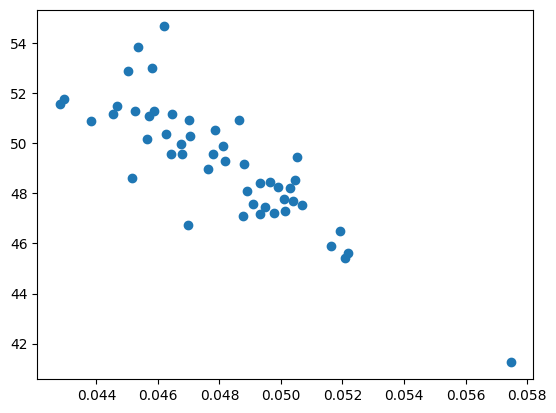

In [ ]:
plt.scatter(hop_height, power/hop_height)
print(np.average(pos_power/hop_height))